Training samples: 25000
Test samples: 25000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 106ms/step - accuracy: 0.7900 - loss: 0.4489 - val_accuracy: 0.8622 - val_loss: 0.3354
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 108ms/step - accuracy: 0.8964 - loss: 0.2707 - val_accuracy: 0.8662 - val_loss: 0.3227
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - accuracy: 0.9181 - loss: 0.2161 - val_accuracy: 0.8688 - val_loss: 0.3563
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.9393 - loss: 0.1722 - val_accuracy: 0.8632 - val_loss: 0.3951
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 107ms/step - accuracy: 0.9246 - loss: 0.1950 - val_accuracy: 0.8590 - val_loss: 0.4054

Test loss: 0.4313
Test accuracy: 0.8533


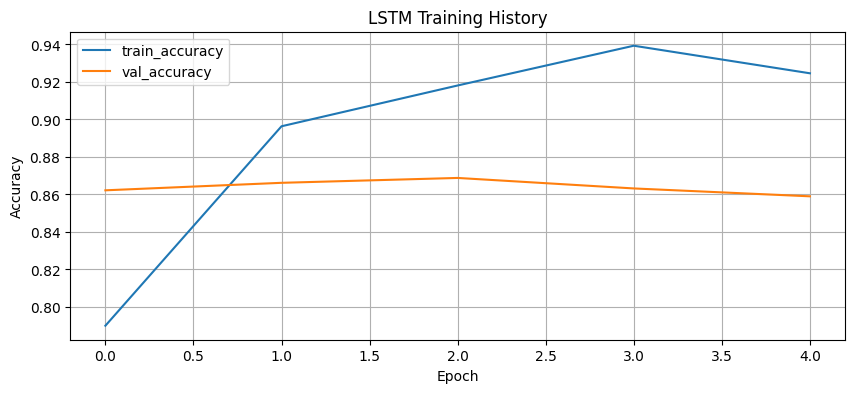


Confusion Matrix:
[[10795  1705]
 [ 1963 10537]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8461    0.8636    0.8548     12500
           1     0.8607    0.8430    0.8518     12500

    accuracy                         0.8533     25000
   macro avg     0.8534    0.8533    0.8533     25000
weighted avg     0.8534    0.8533    0.8533     25000



In [2]:
"""
MA7442: Modelling Data - Lab 9
LSTM for Sequence Classification (IMDB Dataset)
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from sklearn.metrics import confusion_matrix, classification_report

# 1. Setup for Reproducibility
# Setting seeds ensures weight initialization and shuffling are consistent across runs.
np.random.seed(42)
tf.random.set_seed(42)

# 2. Load and Explore the Dataset
# num_words limits the vocabulary to the top 10,000 most frequent words.
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Training samples: {len(x_train)}")
print(f"Test samples: {len(x_test)}")

# 3. Preprocess the Data (Padding/Truncation)
# Standardize sequence length so the LSTM can process data in batches efficiently.
maxlen = 200
x_train_pad = pad_sequences(x_train, maxlen=maxlen)
x_test_pad = pad_sequences(x_test, maxlen=maxlen)

# 4. Design the LSTM Model Architecture
# Architecture: Embedding -> LSTM -> Dropout -> Dense Sigmoid
embed_dim = 64
lstm_units = 64

model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=num_words, output_dim=embed_dim),
    layers.LSTM(lstm_units),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Configure the learning process
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

# 5. Model Training
# Training for 5 epochs with a 20% validation split.
history = model.fit(
    x_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 6. Evaluate on Test Data
# Evaluate performance on completely unseen test data.
score = model.evaluate(x_test_pad, y_test, verbose=0)
print(f"\nTest loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

# 7. Visualize Training Curves
plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 8. Prediction and Detailed Interpretation
# Generating predictions for the full test set.
y_pred_probs = model.predict(x_test_pad, verbose=0).reshape(-1)
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = y_test

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))